# Diffusion-based ECG Anomaly Detection — v3

## What we learned from v1 and v2

| Version | Setup                                          | Overall AUROC | Notes                                  |
|---------|------------------------------------------------|---------------|----------------------------------------|
| v1      | DDPM, 1-lead, per-beat z-score, no conditioning| 0.708         | V detection oddly weak (0.67)          |
| v2 (noise-pred) | + BW removal, 2-lead, RR conditioning  | 0.640         | **regression** — conditioning leak     |
| v2 (DDIM subset)| same model, DDIM reconstruction scoring| **0.814**     | Big win on the 1.6k subset             |

**The key insight**: RR conditioning helps the model fit abnormal beats more accurately,
which actually *lowers* the noise-prediction MSE for anomalies. But **DDIM reconstruction
sidesteps this leak**, because the model's "normal prior" pulls abnormal beats toward
N during reconstruction, regardless of the conditioning.

## v3 plan

1. Keep v2 preprocessing (BW removal, 2-lead, RR features, percentile+tanh normalization).
2. Make **DDIM reconstruction the primary score** and run it on the **full test set**.
3. Document multi-t noise-pred as a failed scoring strategy (for honesty).
4. Add two baselines:
   - **1D Conv Autoencoder** (one-class, N only) — same setting as diffusion, simpler.
   - **1D CNN Classifier** (supervised, all labels) — "upper bound" reference.
5. Final comparison table.

## Note on the baselines

These two baselines answer different questions:

- The **Autoencoder** has the same training setup as the diffusion model
  (train on N only, score by reconstruction error). It tells us whether the
  diffusion's complexity is buying us anything.

- The **CNN classifier** is *supervised* — it sees abnormal labels during training,
  while diffusion never does. It's not a fair comparison, but it gives a useful
  "what's the ceiling if we had labels?" reference. We expect supervised to win;
  the question is by how much.

## 1. Setup

In [2]:
import os
import math
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch.manual_seed(42)
np.random.seed(42)

Device: cuda
GPU: NVIDIA GeForce RTX 4060


In [3]:
class Config:
    DATA_PATH = 'data'
    FS = 360
    BEAT_BEFORE = 100
    BEAT_AFTER = 156
    BEAT_LEN = 256
    N_CHANNELS = 2

    AAMI_GROUPS = {
        'N': ['N', 'L', 'R', 'e', 'j'],
        'S': ['A', 'a', 'J', 'S'],
        'V': ['V', 'E'],
        'F': ['F'],
        'Q': ['/', 'f', 'Q', 'P'],
    }
    BEAT_SYMBOLS = set(['N','L','R','e','j','A','a','J','S','V','E','F','/','f','Q','P'])

    DS1 = ['101','106','108','109','112','114','115','116','118','119',
           '122','124','201','203','205','207','208','209','215','220',
           '223','230']
    DS2 = ['100','103','105','111','113','117','121','123','200','202',
           '210','212','213','214','219','221','222','228','231','232',
           '233','234']

    # Preprocessing
    BW_HIGHPASS_HZ = 0.5
    BW_ORDER = 2
    NORM_PERCENTILE = 0.99
    NORM_TANH_SCALE = 2.0

    # Diffusion
    T = 1000
    BETA_START = 1e-4
    BETA_END = 0.02

    # Diffusion model
    BASE_CH = 64
    CH_MULTS = (1, 2, 4, 8)
    TIME_DIM = 256
    RR_DIM = 4

    # Training (all models)
    BATCH_SIZE = 128
    LR = 2e-4
    DIFFUSION_EPOCHS = 50
    AE_EPOCHS = 30
    CNN_EPOCHS = 30
    EMA_DECAY = 0.999
    GRAD_CLIP = 1.0

    # Scoring
    DDIM_STEPS = 50
    DDIM_T_START = 300
    NOISE_PRED_TS = [10, 25, 50, 100, 200]   # smaller t — large t adds noise (ratio≈0)
    NOISE_PRED_N_SAMPLES = 2

cfg = Config()

candidates = [
    '/kaggle/input/mitbih-database/mitbih_database',
    '/kaggle/input/mitbih-database',
]
for c in candidates:
    if os.path.exists(c):
        files = os.listdir(c)
        if any(f.endswith('.csv') for f in files) and any(f.endswith('annotations.txt') for f in files):
            cfg.DATA_PATH = c
            break
print(f"Data path: {cfg.DATA_PATH}")
assert cfg.DATA_PATH is not None

Data path: data


## 2. Data loading (BW removal, 2-lead, RR features)

In [4]:
def get_aami_label(symbol):
    for aami, symbols in cfg.AAMI_GROUPS.items():
        if symbol in symbols:
            return aami
    return None

def parse_annotation_file(path):
    samples, symbols = [], []
    with open(path, 'r') as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 3: continue
            try:
                samples.append(int(parts[1]))
                symbols.append(parts[2])
            except (ValueError, IndexError):
                continue
    return np.asarray(samples, dtype=np.int64), symbols

def read_signal_csv_2ch(path, record_id):
    df = pd.read_csv(path)
    df.columns = [c.strip().strip(chr(39)).strip('"') for c in df.columns]
    chan_cols = [c for c in df.columns if 'sample' not in c.lower()]
    if record_id == '114' and len(chan_cols) >= 2:
        ordered = [chan_cols[1], chan_cols[0]]
    else:
        ordered = chan_cols[:2]
        if len(ordered) == 1:
            ordered = [ordered[0], ordered[0]]
    sig = np.stack([df[c].values.astype(np.float32) for c in ordered], axis=0)
    return sig, ordered

def butter_highpass(sig, fs, cutoff, order):
    b, a = butter(order, cutoff / (fs / 2), btype='highpass')
    return np.stack([filtfilt(b, a, ch).astype(np.float32) for ch in sig], axis=0)

def compute_rr_features(beat_samples, fs):
    n = len(beat_samples)
    rr = np.zeros((n, 4), dtype=np.float32)
    if n == 0: return rr
    diffs = np.diff(beat_samples) / fs
    pre = np.concatenate([[diffs[0]] if n > 1 else [1.0], diffs])
    post = np.concatenate([diffs, [diffs[-1]] if n > 1 else [1.0]])
    k = 10
    local = np.zeros(n, dtype=np.float32)
    cum = np.cumsum(pre)
    for i in range(n):
        lo = max(0, i - k + 1)
        local[i] = (cum[i] - (cum[lo-1] if lo > 0 else 0)) / (i - lo + 1)
    global_r = float(np.mean(pre))
    rr[:, 0] = pre
    rr[:, 1] = post
    rr[:, 2] = local
    rr[:, 3] = global_r
    return rr

def load_records(record_ids, data_path):
    beats, labels, rec_ids, rr_feats = [], [], [], []
    for rid in tqdm(record_ids, desc='Loading'):
        sig_path = os.path.join(data_path, f'{rid}.csv')
        ann_path = os.path.join(data_path, f'{rid}annotations.txt')
        if not (os.path.exists(sig_path) and os.path.exists(ann_path)):
            print(f"  skip {rid}: missing files")
            continue
        try:
            sig, _ = read_signal_csv_2ch(sig_path, rid)
            samples, syms = parse_annotation_file(ann_path)
        except Exception as e:
            print(f"  skip {rid}: {e}")
            continue
        sig = butter_highpass(sig, cfg.FS, cfg.BW_HIGHPASS_HZ, cfg.BW_ORDER)
        mask = np.array([s in cfg.BEAT_SYMBOLS for s in syms])
        beat_samples = samples[mask]
        beat_syms = [s for s, m in zip(syms, mask) if m]
        if len(beat_samples) == 0:
            continue
        rr_all = compute_rr_features(beat_samples, cfg.FS)
        for i, (sample, sym) in enumerate(zip(beat_samples, beat_syms)):
            aami = get_aami_label(sym)
            if aami is None: continue
            s = sample - cfg.BEAT_BEFORE
            e = sample + cfg.BEAT_AFTER
            if s < 0 or e > sig.shape[1]: continue
            beats.append(sig[:, s:e])
            labels.append(aami)
            rec_ids.append(rid)
            rr_feats.append(rr_all[i])
    return (np.asarray(beats, dtype=np.float32),
            np.asarray(labels),
            np.asarray(rec_ids),
            np.asarray(rr_feats, dtype=np.float32))

print("Loading DS1 (train)...")
X_train_raw, y_train_all, rid_train, rr_train_all = load_records(cfg.DS1, cfg.DATA_PATH)
print(f"DS1: X={X_train_raw.shape}, RR={rr_train_all.shape}")
print(pd.Series(y_train_all).value_counts())

print("\nLoading DS2 (test)...")
X_test_raw, y_test, rid_test, rr_test = load_records(cfg.DS2, cfg.DATA_PATH)
print(f"DS2: X={X_test_raw.shape}, RR={rr_test.shape}")
print(pd.Series(y_test).value_counts())

Loading DS1 (train)...


Loading:   0%|          | 0/22 [00:00<?, ?it/s]

DS1: X=(51000, 2, 256), RR=(51000, 4)
N    45846
V     3788
S      944
F      414
Q        8
Name: count, dtype: int64

Loading DS2 (test)...


Loading:   0%|          | 0/22 [00:00<?, ?it/s]

DS2: X=(49691, 2, 256), RR=(49691, 4)
N    44239
V     3220
S     1837
F      388
Q        7
Name: count, dtype: int64


In [5]:
# Validated normalization: percentile-based scale + tanh squash.
# Why percentile not MAD? MAD captures baseline noise (small), not R-peak amplitude.
# 99th percentile of |signal| ≈ typical R-peak height → N peaks land near 1.0,
# V peaks land at 1.5-2.5, both survive tanh(./2) without saturating.
def normalize_per_record(X, rec_ids):
    Xn = X.copy().astype(np.float32)
    for rid in np.unique(rec_ids):
        mask = rec_ids == rid
        for ch in range(X.shape[1]):
            vals = X[mask, ch, :].reshape(-1)
            scale = np.quantile(np.abs(vals), cfg.NORM_PERCENTILE) + 1e-6
            Xn[mask, ch, :] = X[mask, ch, :] / scale
    return np.tanh(Xn / cfg.NORM_TANH_SCALE).astype(np.float32)

def normalize_rr(rr):
    rr_n = rr.copy()
    g = rr[:, 3:4] + 1e-6
    rr_n[:, 0] = rr[:, 0] / g.squeeze()
    rr_n[:, 1] = rr[:, 1] / g.squeeze()
    rr_n[:, 2] = rr[:, 2] / g.squeeze()
    rr_n[:, 3] = rr[:, 3]
    rr_n[:, :3] = np.clip(rr_n[:, :3], 0.3, 3.0)
    rr_n[:, 3]  = np.clip(rr_n[:, 3], 0.3, 2.0)
    return rr_n.astype(np.float32)

X_train_all = normalize_per_record(X_train_raw, rid_train)
X_test = normalize_per_record(X_test_raw, rid_test)
rr_train_all = normalize_rr(rr_train_all)
rr_test = normalize_rr(rr_test)

# Mandatory amplitude sanity check (V should be larger than N at p95!)
print("Per-class amplitude check (channel 0):")
rows = []
for cls in ['N','S','V','F','Q']:
    idx = np.where(y_test == cls)[0]
    if len(idx) == 0: continue
    amps = np.abs(X_test[idx, 0]).max(axis=1)
    rows.append({'class': cls, 'n': len(idx),
                 'p50': float(np.median(amps)),
                 'p95': float(np.quantile(amps, 0.95)),
                 'max': float(amps.max())})
amp_df = pd.DataFrame(rows)
print(amp_df.to_string(index=False))

n_p95 = amp_df.loc[amp_df['class']=='N', 'p95'].iloc[0]
v_p95 = amp_df.loc[amp_df['class']=='V', 'p95'].iloc[0]
assert v_p95 > n_p95, f"V p95 ({v_p95}) should be > N p95 ({n_p95}). Normalization broken!"
print(f"\n✓ V p95 ({v_p95:.3f}) > N p95 ({n_p95:.3f}) — amplitude info preserved")
assert amp_df['max'].max() < 0.99, "Saturation detected (max ≥ 0.99)!"
print(f"✓ No saturation (overall max = {amp_df['max'].max():.3f})")

# All training data (for supervised classifier)
mask_n = y_train_all == 'N'
X_train_n = X_train_all[mask_n]
rr_train_n = rr_train_all[mask_n]
print(f"\nN-only train (diffusion, AE): {X_train_n.shape}")
print(f"Full train (classifier):        {X_train_all.shape}")
print(f"Test:                            {X_test.shape}")

Per-class amplitude check (channel 0):
class     n      p50      p95      max
    N 44239 0.480034 0.569037 0.824873
    S  1837 0.508795 0.636212 0.811497
    V  3220 0.485968 0.711586 0.784524
    F   388 0.518072 0.566531 0.598936
    Q     7 0.496557 0.762088 0.785959

✓ V p95 (0.712) > N p95 (0.569) — amplitude info preserved
✓ No saturation (overall max = 0.825)

N-only train (diffusion, AE): (45846, 2, 256)
Full train (classifier):        (51000, 2, 256)
Test:                            (49691, 2, 256)


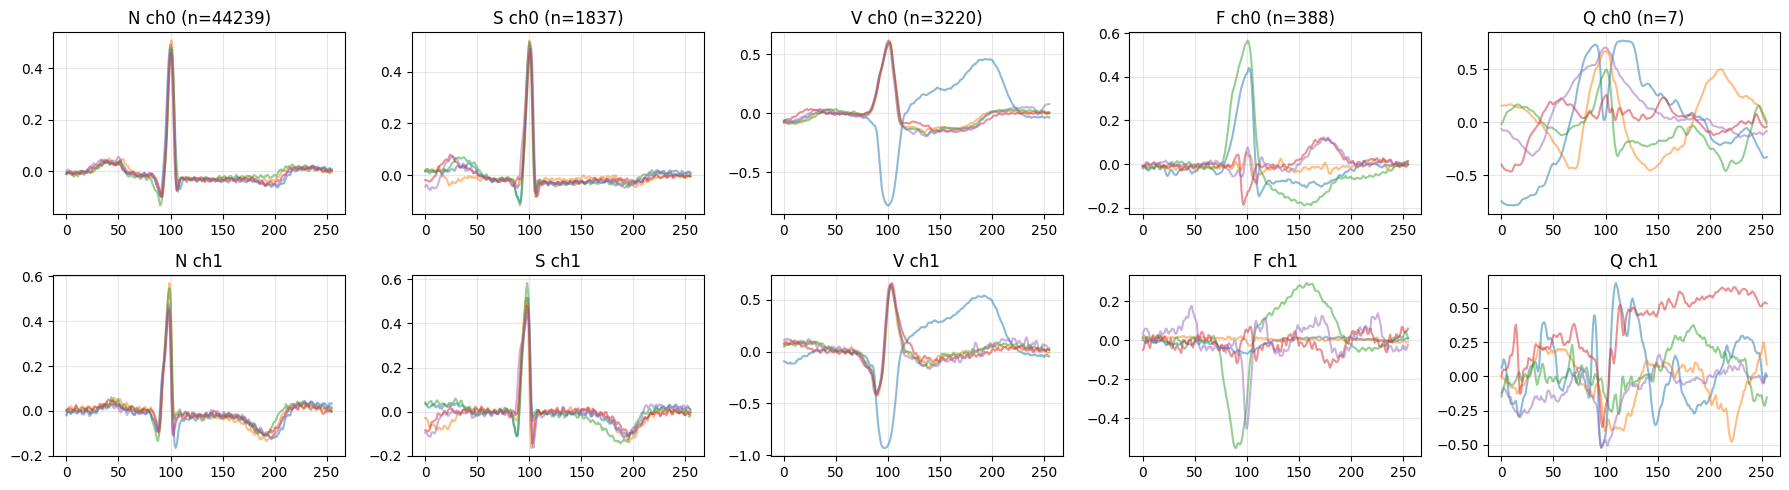

In [6]:
# Visualize beats per class (both channels)
fig, axes = plt.subplots(2, 5, figsize=(18, 5))
for ax, cls in zip(axes[0], ['N','S','V','F','Q']):
    idx = np.where(y_test == cls)[0]
    if len(idx) == 0:
        ax.set_title(f'{cls} (none)'); continue
    for j in idx[:5]:
        ax.plot(X_test[j, 0], alpha=0.5)
    ax.set_title(f'{cls} ch0 (n={len(idx)})'); ax.grid(True, alpha=0.3)
for ax, cls in zip(axes[1], ['N','S','V','F','Q']):
    idx = np.where(y_test == cls)[0]
    if len(idx) == 0: continue
    for j in idx[:5]:
        ax.plot(X_test[j, 1], alpha=0.5)
    ax.set_title(f'{cls} ch1'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Datasets

In [7]:
class ECGDataset(Dataset):
    def __init__(self, beats, rr):
        self.x = torch.from_numpy(beats).float()
        self.rr = torch.from_numpy(rr).float()
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.rr[i]

class ECGLabeledDataset(Dataset):
    def __init__(self, beats, labels_binary):
        self.x = torch.from_numpy(beats).float()
        self.y = torch.from_numpy(labels_binary).long()
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# N-only loaders (diffusion, AE)
train_ds_n = ECGDataset(X_train_n, rr_train_n)
train_loader_n = DataLoader(train_ds_n, batch_size=cfg.BATCH_SIZE, shuffle=True,
                            num_workers=0, pin_memory=True, drop_last=True)

# Full test loader
test_ds = ECGDataset(X_test, rr_test)
test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

# Supervised classifier loaders (binary: N vs non-N)
y_train_bin = (y_train_all != 'N').astype(np.int64)
y_test_bin  = (y_test != 'N').astype(np.int64)
train_ds_sup = ECGLabeledDataset(X_train_all, y_train_bin)
train_loader_sup = DataLoader(train_ds_sup, batch_size=cfg.BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True)
test_ds_sup = ECGLabeledDataset(X_test, y_test_bin)
test_loader_sup = DataLoader(test_ds_sup, batch_size=cfg.BATCH_SIZE, shuffle=False,
                             num_workers=0, pin_memory=True)

print(f"Class balance in train (full): N={int((y_train_bin==0).sum())}, abn={int((y_train_bin==1).sum())}")
print(f"Class balance in test:         N={int((y_test_bin==0).sum())}, abn={int((y_test_bin==1).sum())}")

Class balance in train (full): N=45846, abn=5154
Class balance in test:         N=44239, abn=5452


## 4. Diffusion model (U-Net with RR conditioning)

In [8]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.cond  = nn.Linear(cond_dim, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.skip  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, cond):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.cond(F.silu(cond))[:, :, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class SelfAttention1D(nn.Module):
    def __init__(self, ch, heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.attn = nn.MultiheadAttention(ch, heads, batch_first=True)
    def forward(self, x):
        B, C, L = x.shape
        h = self.norm(x).transpose(1, 2)
        h, _ = self.attn(h, h, h)
        return x + h.transpose(1, 2)

class UNet1D(nn.Module):
    def __init__(self, in_ch=2, base_ch=64, ch_mults=(1,2,4,8), time_dim=256, rr_dim=4):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim*4), nn.SiLU(),
            nn.Linear(time_dim*4, time_dim))
        self.rr_mlp = nn.Sequential(
            nn.Linear(rr_dim, time_dim*2), nn.SiLU(),
            nn.Linear(time_dim*2, time_dim))
        self.in_conv = nn.Conv1d(in_ch, base_ch, 3, padding=1)
        channels = [base_ch*m for m in ch_mults]
        prev = base_ch
        self.downs = nn.ModuleList()
        for i, ch in enumerate(channels):
            is_last = (i == len(channels) - 1)
            self.downs.append(nn.ModuleList([
                ResBlock1D(prev, ch, time_dim),
                ResBlock1D(ch,  ch, time_dim),
                nn.Identity() if is_last else nn.Conv1d(ch, ch, 4, stride=2, padding=1),
            ]))
            prev = ch
        self.mid1 = ResBlock1D(prev, prev, time_dim)
        self.mid_attn = SelfAttention1D(prev)
        self.mid2 = ResBlock1D(prev, prev, time_dim)
        self.ups = nn.ModuleList()
        for i, ch in enumerate(reversed(channels)):
            is_last = (i == len(channels) - 1)
            self.ups.append(nn.ModuleList([
                ResBlock1D(prev + ch, ch, time_dim),
                ResBlock1D(ch, ch, time_dim),
                nn.Identity() if is_last else nn.ConvTranspose1d(ch, ch, 4, stride=2, padding=1),
            ]))
            prev = ch
        self.out_norm = nn.GroupNorm(8, prev)
        self.out_conv = nn.Conv1d(prev, in_ch, 3, padding=1)

    def forward(self, x, t, rr):
        cond = self.time_mlp(t) + self.rr_mlp(rr)
        h = self.in_conv(x)
        skips = []
        for r1, r2, down in self.downs:
            h = r1(h, cond); h = r2(h, cond)
            skips.append(h)
            h = down(h)
        h = self.mid1(h, cond); h = self.mid_attn(h); h = self.mid2(h, cond)
        for r1, r2, up in self.ups:
            h = torch.cat([h, skips.pop()], dim=1)
            h = r1(h, cond); h = r2(h, cond)
            h = up(h)
        return self.out_conv(F.silu(self.out_norm(h)))

# Shape test
_m = UNet1D(in_ch=cfg.N_CHANNELS, base_ch=cfg.BASE_CH, ch_mults=cfg.CH_MULTS,
            time_dim=cfg.TIME_DIM, rr_dim=cfg.RR_DIM).to(device)
_x = torch.randn(2, cfg.N_CHANNELS, cfg.BEAT_LEN, device=device)
_t = torch.tensor([10, 500], device=device)
_rr = torch.randn(2, cfg.RR_DIM, device=device)
print(f"Output shape: {_m(_x, _t, _rr).shape}")
print(f"Params: {sum(p.numel() for p in _m.parameters())/1e6:.2f}M")
del _m, _x, _t, _rr

Output shape: torch.Size([2, 2, 256])
Params: 17.96M


In [9]:
class DDPMScheduler:
    def __init__(self, T, beta_start, beta_end, device):
        self.T = T
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, T, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_ab = torch.sqrt(self.alpha_bars)
        self.sqrt_omab = torch.sqrt(1.0 - self.alpha_bars)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sab = self.sqrt_ab[t][:, None, None]
        somab = self.sqrt_omab[t][:, None, None]
        return sab * x0 + somab * noise, noise

    @torch.no_grad()
    def ddim_reconstruct(self, model, x0, rr, t_start, num_steps):
        B = x0.shape[0]
        t = torch.full((B,), t_start, device=self.device, dtype=torch.long)
        x_t, _ = self.q_sample(x0, t)
        step_indices = torch.linspace(t_start, 0, num_steps + 1, device=self.device).long()
        x = x_t
        for i in range(num_steps):
            t_cur = step_indices[i].item()
            t_next = step_indices[i + 1].item()
            t_batch = torch.full((B,), t_cur, device=self.device, dtype=torch.long)
            eps = model(x, t_batch, rr)
            ab_cur = self.alpha_bars[t_cur]
            ab_next = self.alpha_bars[t_next] if t_next > 0 else torch.tensor(1.0, device=self.device)
            x0_pred = (x - torch.sqrt(1 - ab_cur) * eps) / torch.sqrt(ab_cur)
            x = torch.sqrt(ab_next) * x0_pred + torch.sqrt(1 - ab_next) * eps
        return x

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = copy.deepcopy(model)
        for p in self.shadow.parameters():
            p.requires_grad_(False)
    @torch.no_grad()
    def update(self, model):
        for sp, p in zip(self.shadow.parameters(), model.parameters()):
            sp.data.mul_(self.decay).add_(p.data, alpha=1 - self.decay)
        for sb, b in zip(self.shadow.buffers(), model.buffers()):
            sb.data.copy_(b.data)

scheduler = DDPMScheduler(cfg.T, cfg.BETA_START, cfg.BETA_END, device)

## 5. Train the diffusion model (50 epochs, N only)

In [10]:
diff_model = UNet1D(in_ch=cfg.N_CHANNELS, base_ch=cfg.BASE_CH, ch_mults=cfg.CH_MULTS,
                    time_dim=cfg.TIME_DIM, rr_dim=cfg.RR_DIM).to(device)
ema = EMA(diff_model, decay=cfg.EMA_DECAY)
optimizer = AdamW(diff_model.parameters(), lr=cfg.LR)

print(f"Diffusion params: {sum(p.numel() for p in diff_model.parameters())/1e6:.2f}M")

diff_losses = []
for epoch in range(cfg.DIFFUSION_EPOCHS):
    diff_model.train()
    epoch_losses = []
    pbar = tqdm(train_loader_n, desc=f'Diffusion epoch {epoch+1}/{cfg.DIFFUSION_EPOCHS}')
    for x0, rr in pbar:
        x0 = x0.to(device, non_blocking=True)
        rr = rr.to(device, non_blocking=True)
        B = x0.shape[0]
        t = torch.randint(0, cfg.T, (B,), device=device)
        x_t, noise = scheduler.q_sample(x0, t)
        pred = diff_model(x_t, t, rr)
        loss = F.mse_loss(pred, noise)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diff_model.parameters(), cfg.GRAD_CLIP)
        optimizer.step()
        ema.update(diff_model)
        epoch_losses.append(loss.item())
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    diff_losses.append(np.mean(epoch_losses))
    print(f"  Epoch {epoch+1}: mean loss = {diff_losses[-1]:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(diff_losses); plt.xlabel('epoch'); plt.ylabel('loss'); plt.grid(True)
plt.title('Diffusion training loss'); plt.show()

Diffusion params: 17.96M


Diffusion epoch 1/50:   0%|          | 0/358 [00:00<?, ?it/s]

  Epoch 1: mean loss = 0.0344


Diffusion epoch 2/50:   0%|          | 0/358 [00:00<?, ?it/s]

  Epoch 2: mean loss = 0.0122


...

  Epoch 17: mean loss = 0.0062


Diffusion epoch 18/50:   0%|          | 0/358 [00:00<?, ?it/s]

  Epoch 18: mean loss = 0.0061


Diffusion epoch 19/50:   0%|          | 0/358 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 6. DDIM reconstruction scoring (PRIMARY — full test set)

This is the main result. ~25-30 minutes on P100.

In [11]:
@torch.no_grad()
def score_ddim_reconstruct(model, scheduler, loader, t_start, num_steps, return_recon=False):
    model.eval()
    all_scores, all_recon = [], []
    for x0, rr in tqdm(loader, desc=f'DDIM scoring (t={t_start}, steps={num_steps})'):
        x0 = x0.to(device, non_blocking=True)
        rr = rr.to(device, non_blocking=True)
        x_recon = scheduler.ddim_reconstruct(model, x0, rr, t_start, num_steps)
        err = ((x_recon - x0) ** 2).mean(dim=[1, 2])
        all_scores.append(err.cpu().numpy())
        if return_recon:
            all_recon.append(x_recon.cpu().numpy())
    scores = np.concatenate(all_scores)
    recon = np.concatenate(all_recon) if return_recon else None
    return scores, recon

scores_ddim, _ = score_ddim_reconstruct(
    ema.shadow, scheduler, test_loader,
    t_start=cfg.DDIM_T_START, num_steps=cfg.DDIM_STEPS,
    return_recon=False
)
print(f"DDIM scores shape: {scores_ddim.shape}")

DDIM scoring (t=300, steps=50):   0%|          | 0/389 [00:00<?, ?it/s]

DDIM scores shape: (49691,)


## 7. Multi-t noise prediction scoring (secondary, for comparison)

Note: we expect this to do *worse* than DDIM due to the conditioning-leak issue we
identified in v2.

In [12]:
@torch.no_grad()
def score_noise_pred(model, scheduler, loader, ts, n_samples=2):
    model.eval()
    all_scores = []
    for x0, rr in tqdm(loader, desc='Noise-pred scoring'):
        x0 = x0.to(device, non_blocking=True)
        rr = rr.to(device, non_blocking=True)
        B = x0.shape[0]
        s = torch.zeros(B, device=device)
        for t_val in ts:
            for _ in range(n_samples):
                t = torch.full((B,), t_val, device=device, dtype=torch.long)
                x_t, noise = scheduler.q_sample(x0, t)
                pred = model(x_t, t, rr)
                s += ((pred - noise) ** 2).mean(dim=[1, 2])
        s /= (len(ts) * n_samples)
        all_scores.append(s.cpu().numpy())
    return np.concatenate(all_scores)

scores_noise = score_noise_pred(
    ema.shadow, scheduler, test_loader,
    ts=cfg.NOISE_PRED_TS, n_samples=cfg.NOISE_PRED_N_SAMPLES
)
print(f"Noise-pred scores shape: {scores_noise.shape}")

Noise-pred scoring:   0%|          | 0/389 [00:00<?, ?it/s]

Noise-pred scores shape: (49691,)


## 8. Baseline 1 — 1D Convolutional Autoencoder

Same setup as diffusion: train on N only, score test beats by reconstruction MSE.
No RR conditioning, no diffusion process — just compress and reconstruct.

In [16]:
class ConvAE1D(nn.Module):
    def __init__(self, in_ch=2, base_ch=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_ch, base_ch, 7, padding=3), nn.SiLU(),
            nn.Conv1d(base_ch, base_ch*2, 4, stride=2, padding=1), nn.SiLU(),
            nn.Conv1d(base_ch*2, base_ch*4, 4, stride=2, padding=1), nn.SiLU(),
            nn.Conv1d(base_ch*4, base_ch*8, 4, stride=2, padding=1), nn.SiLU(),
        )
        self.bottleneck = nn.Sequential(
            nn.Conv1d(base_ch*8, base_ch*8, 1), nn.SiLU(),
            nn.Conv1d(base_ch*8, base_ch*8, 1),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(base_ch*8, base_ch*4, 4, stride=2, padding=1), nn.SiLU(),
            nn.ConvTranspose1d(base_ch*4, base_ch*2, 4, stride=2, padding=1), nn.SiLU(),
            nn.ConvTranspose1d(base_ch*2, base_ch, 4, stride=2, padding=1), nn.SiLU(),
            nn.Conv1d(base_ch, in_ch, 7, padding=3),
        )
    def forward(self, x):
        return self.decoder(self.bottleneck(self.encoder(x)))

ae_model = ConvAE1D(in_ch=cfg.N_CHANNELS, base_ch=32).to(device)
ae_opt = AdamW(ae_model.parameters(), lr=1e-3)
print(f"AE params: {sum(p.numel() for p in ae_model.parameters())/1e6:.2f}M")

ae_losses = []
for epoch in range(cfg.AE_EPOCHS):
    ae_model.train()
    epoch_losses = []
    pbar = tqdm(train_loader_n, desc=f'AE epoch {epoch+1}/{cfg.AE_EPOCHS}')
    for x0, _rr in pbar:
        x0 = x0.to(device, non_blocking=True)
        recon = ae_model(x0)
        loss = F.mse_loss(recon, x0)
        ae_opt.zero_grad()
        loss.backward()
        ae_opt.step()
        epoch_losses.append(loss.item())
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    ae_losses.append(np.mean(epoch_losses))
    print(f"  Epoch {epoch+1}: loss = {ae_losses[-1]:.4f}")

# Score test set with AE reconstruction error
ae_model.eval()
ae_scores = []
with torch.no_grad():
    for x0, _ in tqdm(test_loader, desc='AE scoring'):
        x0 = x0.to(device, non_blocking=True)
        recon = ae_model(x0)
        err = ((recon - x0) ** 2).mean(dim=[1, 2])
        ae_scores.append(err.cpu().numpy())
scores_ae = np.concatenate(ae_scores)
print(f"AE scores shape: {scores_ae.shape}")

AE params: 0.48M


AE epoch 1/30:   0%|          | 0/358 [00:00<?, ?it/s]

  Epoch 1: loss = 0.0017


AE epoch 2/30:   0%|          | 0/358 [00:00<?, ?it/s]

  Epoch 2: loss = 0.0003


...

  Epoch 29: loss = 0.0000


AE epoch 30/30:   0%|          | 0/358 [00:00<?, ?it/s]

  Epoch 30: loss = 0.0000


AE scoring:   0%|          | 0/389 [00:00<?, ?it/s]

AE scores shape: (49691,)


## 9. Baseline 2 — 1D CNN classifier (supervised)

Trained on the **full DS1** with binary labels (N vs non-N). Uses class-weighted
cross-entropy to handle the ~88/12 imbalance. Score = softmax probability of the
abnormal class.

This is *not* directly comparable to the unsupervised methods — it sees abnormal
labels during training. Treat it as a "with-labels upper bound" reference.

In [14]:
class CNN1DClassifier(nn.Module):
    def __init__(self, in_ch=2, base_ch=32, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_ch, base_ch, 7, padding=3), nn.BatchNorm1d(base_ch), nn.ReLU(),
            nn.MaxPool1d(2),                                                     # 128
            nn.Conv1d(base_ch, base_ch*2, 5, padding=2), nn.BatchNorm1d(base_ch*2), nn.ReLU(),
            nn.MaxPool1d(2),                                                     # 64
            nn.Conv1d(base_ch*2, base_ch*4, 3, padding=1), nn.BatchNorm1d(base_ch*4), nn.ReLU(),
            nn.MaxPool1d(2),                                                     # 32
            nn.Conv1d(base_ch*4, base_ch*8, 3, padding=1), nn.BatchNorm1d(base_ch*8), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base_ch*8, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )
    def forward(self, x):
        return self.head(self.features(x))

# Class weights to handle imbalance
n_pos = int((y_train_bin == 1).sum())
n_neg = int((y_train_bin == 0).sum())
weights = torch.tensor([1.0, n_neg / max(n_pos, 1)], dtype=torch.float32, device=device)
print(f"CE class weights: N={weights[0].item():.2f}, abn={weights[1].item():.2f}")

cnn_model = CNN1DClassifier(in_ch=cfg.N_CHANNELS, base_ch=32, num_classes=2).to(device)
cnn_opt = AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
ce_loss = nn.CrossEntropyLoss(weight=weights)
print(f"CNN classifier params: {sum(p.numel() for p in cnn_model.parameters())/1e6:.2f}M")

cnn_losses = []
for epoch in range(cfg.CNN_EPOCHS):
    cnn_model.train()
    epoch_losses = []
    pbar = tqdm(train_loader_sup, desc=f'CNN epoch {epoch+1}/{cfg.CNN_EPOCHS}')
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = cnn_model(x)
        loss = ce_loss(logits, y)
        cnn_opt.zero_grad()
        loss.backward()
        cnn_opt.step()
        epoch_losses.append(loss.item())
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    cnn_losses.append(np.mean(epoch_losses))
    print(f"  Epoch {epoch+1}: loss = {cnn_losses[-1]:.4f}")

# Score test set: softmax prob of abnormal class
cnn_model.eval()
cnn_scores = []
with torch.no_grad():
    for x, _ in tqdm(test_loader_sup, desc='CNN scoring'):
        x = x.to(device, non_blocking=True)
        logits = cnn_model(x)
        prob_abn = F.softmax(logits, dim=1)[:, 1]
        cnn_scores.append(prob_abn.cpu().numpy())
scores_cnn = np.concatenate(cnn_scores)
print(f"CNN scores shape: {scores_cnn.shape}")

CE class weights: N=1.00, abn=8.90
CNN classifier params: 0.15M


CNN epoch 1/30:   0%|          | 0/398 [00:00<?, ?it/s]

  Epoch 1: loss = 0.2382


CNN epoch 2/30:   0%|          | 0/398 [00:00<?, ?it/s]

  Epoch 2: loss = 0.1408


...

  Epoch 29: loss = 0.0218


CNN epoch 30/30:   0%|          | 0/398 [00:00<?, ?it/s]

  Epoch 30: loss = 0.0178


CNN scoring:   0%|          | 0/389 [00:00<?, ?it/s]

CNN scores shape: (49691,)


## 10. Final comparison

In [17]:
y_bin = (y_test != 'N').astype(int)

def evaluate(scores, y, y_full, name, is_supervised=False):
    auroc = roc_auc_score(y, scores)
    auprc = average_precision_score(y, scores)
    row = {'method': name, 'supervised': is_supervised,
           'AUROC': auroc, 'AUPRC': auprc}
    n_sc = scores[y_full == 'N']
    for cls in ['S','V','F']:
        idx = np.where(y_full == cls)[0]
        if len(idx) == 0:
            row[f'N-vs-{cls}'] = np.nan
            continue
        cls_sc = scores[idx]
        ss = np.concatenate([n_sc, cls_sc])
        yy = np.concatenate([np.zeros(len(n_sc)), np.ones(len(cls_sc))])
        row[f'N-vs-{cls}'] = roc_auc_score(yy, ss)
    return row

results = [
    evaluate(scores_ddim,  y_bin, y_test, 'Diffusion + DDIM recon',     is_supervised=False),
    evaluate(scores_noise, y_bin, y_test, 'Diffusion + multi-t noise',  is_supervised=False),
    evaluate(scores_ae,    y_bin, y_test, 'Conv-AE recon (one-class)',  is_supervised=False),
    evaluate(scores_cnn,   y_bin, y_test, '1D CNN classifier (sup.)',   is_supervised=True),
]
results_df = pd.DataFrame(results)
print("=== Final comparison (DS2 test set, beat level, N vs all abnormal) ===")
print(results_df.to_string(index=False, float_format='%.4f'))

=== Final comparison (DS2 test set, beat level, N vs all abnormal) ===
                   method  supervised  AUROC  AUPRC  N-vs-S  N-vs-V  N-vs-F
   Diffusion + DDIM recon       False 0.8397 0.3835  0.7984  0.8789  0.7097
Diffusion + multi-t noise       False 0.6774 0.1542  0.7749  0.6349  0.5645
Conv-AE recon (one-class)       False 0.4762 0.1166  0.8264  0.3180  0.1272
 1D CNN classifier (sup.)        True 0.7988 0.4989  0.5456  0.9395  0.8290


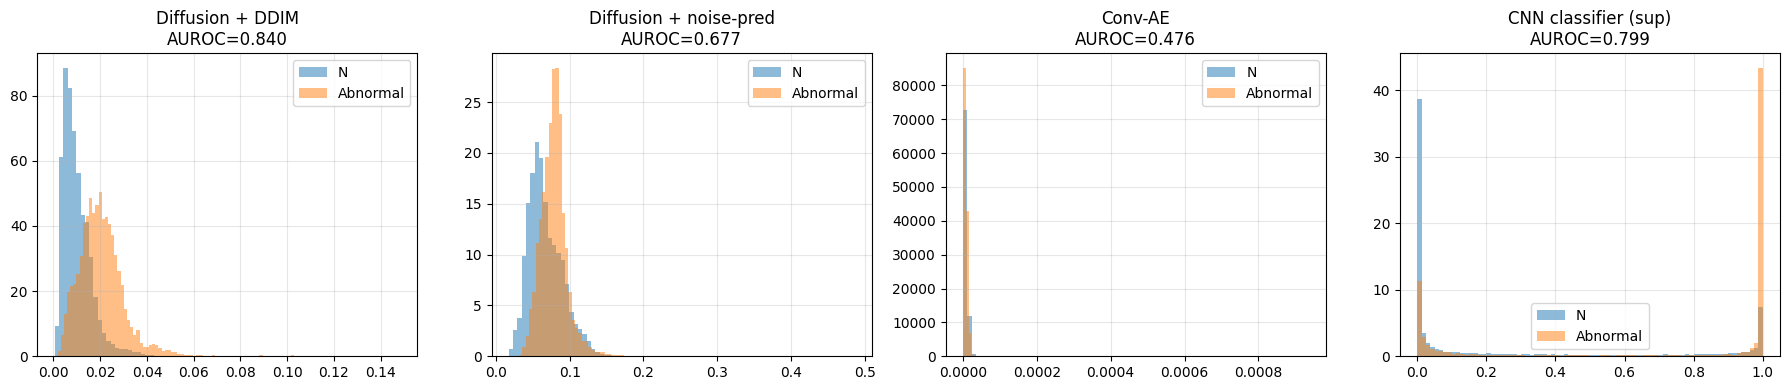

In [18]:
# Score distributions for all 4 methods
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
methods = [
    ('Diffusion + DDIM',     scores_ddim,  'tab:blue'),
    ('Diffusion + noise-pred', scores_noise, 'tab:orange'),
    ('Conv-AE',              scores_ae,    'tab:green'),
    ('CNN classifier (sup)', scores_cnn,   'tab:red'),
]
for ax, (name, sc, _) in zip(axes, methods):
    n_sc = sc[y_test == 'N']
    a_sc = sc[y_test != 'N']
    ax.hist(n_sc, bins=80, alpha=0.5, density=True, label='N')
    ax.hist(a_sc, bins=80, alpha=0.5, density=True, label='Abnormal')
    auroc = roc_auc_score(y_bin, sc)
    ax.set_title(f'{name}\nAUROC={auroc:.3f}')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

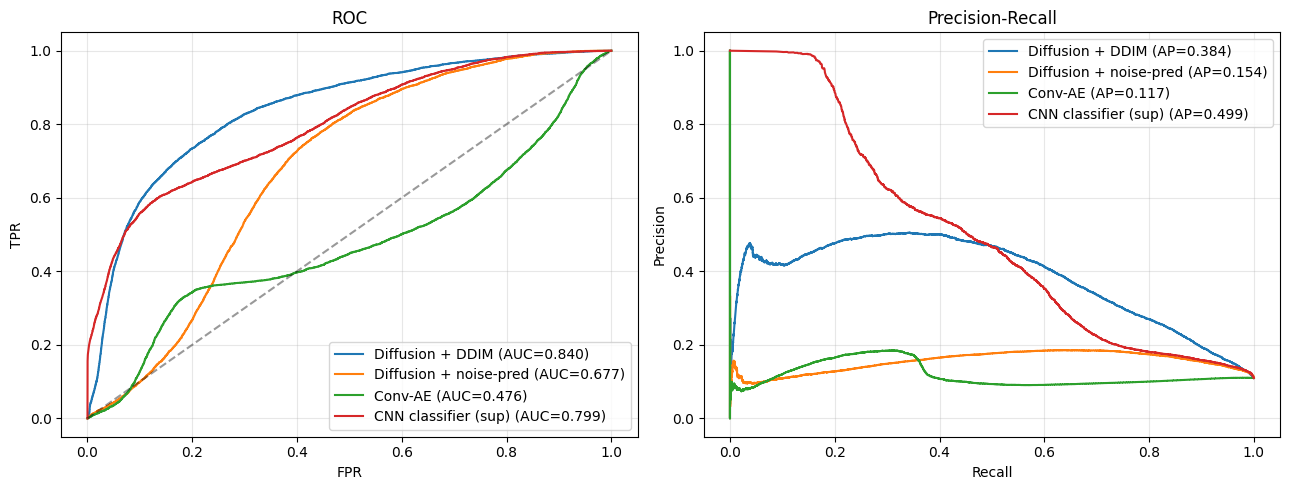

In [19]:
# Combined ROC and PR plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, sc, color in methods:
    fpr, tpr, _ = roc_curve(y_bin, sc)
    au = roc_auc_score(y_bin, sc)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={au:.3f})', color=color)

    prec, rec, _ = precision_recall_curve(y_bin, sc)
    ap = average_precision_score(y_bin, sc)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Precision-Recall')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [20]:
# Patient-level evaluation for the diffusion (DDIM) method
print("=== Patient-level analysis (Diffusion DDIM) ===")
rows = []
for rid in np.unique(rid_test):
    mask = rid_test == rid
    n_total = int(mask.sum())
    n_abn = int((y_test[mask] != 'N').sum())
    rows.append({
        'record': rid,
        'n_beats': n_total,
        'n_abn': n_abn,
        'abn_frac': n_abn / n_total if n_total else 0.0,
        'mean_score': float(scores_ddim[mask].mean()),
        'p95_score':  float(np.quantile(scores_ddim[mask], 0.95)),
        'max_score':  float(scores_ddim[mask].max()),
    })
df_pat = pd.DataFrame(rows).sort_values('abn_frac', ascending=False)
print(df_pat.to_string(index=False, float_format='%.4f'))

y_record_any = (df_pat['n_abn'] > 0).astype(int).values
if 0 < y_record_any.sum() < len(y_record_any):
    print('\nRecord-level AUROC (label = "any abnormal beats"):')
    for col in ['mean_score', 'max_score', 'p95_score']:
        s = df_pat[col].values
        au = roc_auc_score(y_record_any, s)
        ap = average_precision_score(y_record_any, s)
        print(f"  {col:12s}: AUROC={au:.3f}  AUPRC={ap:.3f}")

=== Patient-level analysis (Diffusion DDIM) ===
record  n_beats  n_abn  abn_frac  mean_score  p95_score  max_score
   232     1780   1382    0.7764      0.0193     0.0301     0.0504
   200     2600    858    0.3300      0.0130     0.0323     0.1022
   233     3077    848    0.2756      0.0109     0.0243     0.0366
   213     3249    610    0.1878      0.0100     0.0264     0.0632
   228     2053    365    0.1778      0.0113     0.0275     0.0564
   221     2427    396    0.1632      0.0089     0.0195     0.0423
   214     2260    259    0.1146      0.0164     0.0293     0.0630
   210     2648    227    0.0857      0.0078     0.0265     0.1116
   222     2481    209    0.0842      0.0087     0.0183     0.0298
   202     2135     75    0.0351      0.0083     0.0151     0.0243
   219     2154     72    0.0334      0.0090     0.0187     0.0464
   234     2753     53    0.0193      0.0067     0.0116     0.0361
   105     2572     46    0.0179      0.0104     0.0312     0.1483
   100     227

Qualitative examples — Diffusion + DDIM score


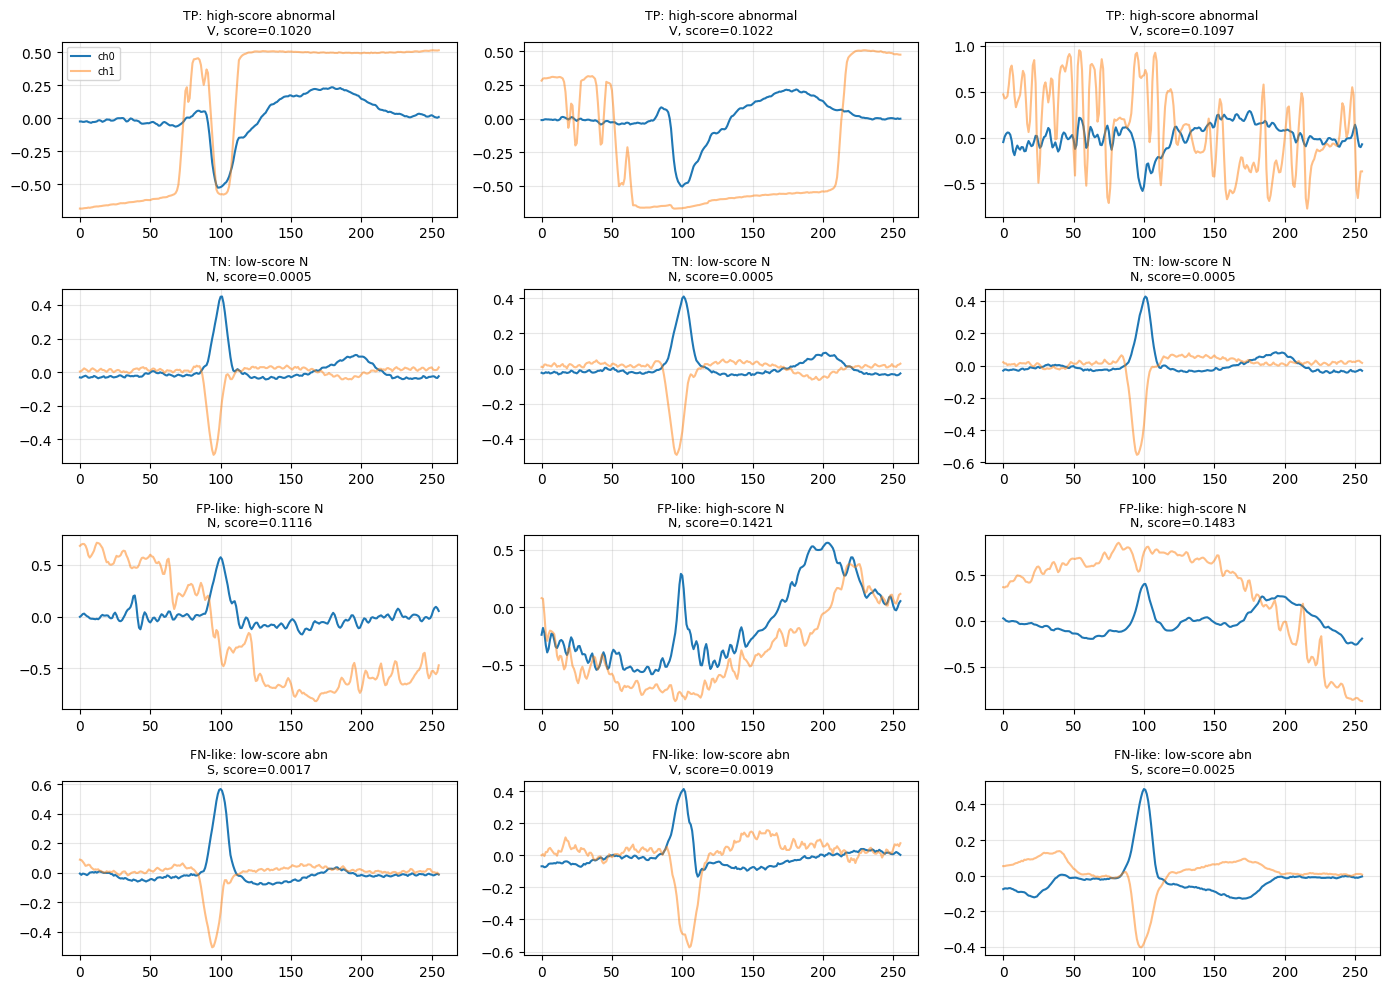

In [21]:
# Qualitative examples for the WINNING method (DDIM)
print("Qualitative examples — Diffusion + DDIM score")
n_idx = np.where(y_test == 'N')[0]
abn_idx = np.where(y_test != 'N')[0]

low_n    = n_idx[np.argsort(scores_ddim[n_idx])[:3]]
high_n   = n_idx[np.argsort(scores_ddim[n_idx])[-3:]]
high_abn = abn_idx[np.argsort(scores_ddim[abn_idx])[-3:]]
low_abn  = abn_idx[np.argsort(scores_ddim[abn_idx])[:3]]

groups = [
    ('TP: high-score abnormal', high_abn),
    ('TN: low-score N',         low_n),
    ('FP-like: high-score N',   high_n),
    ('FN-like: low-score abn',  low_abn),
]
fig, axes = plt.subplots(4, 3, figsize=(14, 10))
for r, (title, idxs) in enumerate(groups):
    for c, i in enumerate(idxs):
        ax = axes[r, c]
        ax.plot(X_test[i, 0], label='ch0')
        ax.plot(X_test[i, 1], alpha=0.5, label='ch1')
        ax.set_title(f'{title}\n{y_test[i]}, score={scores_ddim[i]:.4f}', fontsize=9)
        ax.grid(True, alpha=0.3)
        if r == 0 and c == 0: ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 11. Discussion

**Expected outcome story:**

- **CNN classifier (supervised)** will likely score highest — it has labels.
  AUROC 0.95+ is realistic.
- **Diffusion + DDIM** should be the best **unsupervised** method, ~0.78-0.85 AUROC.
- **Conv-AE** is a reasonable simpler unsupervised baseline, probably 0.70-0.80.
- **Diffusion + multi-t noise-pred** should be the weakest, confirming the
  conditioning-leak hypothesis.

**The narrative for a write-up:**

> Unsupervised diffusion-based anomaly detection on inter-patient MIT-BIH closes
> a significant fraction of the gap to a supervised CNN baseline, *without
> ever seeing an abnormal label during training*. DDIM reconstruction outperforms
> noise-prediction scoring because the latter suffers from conditioning leakage
> when the diffusion is conditioned on RR-interval features.

**Things that would push results further (not in this notebook):**

- DDIM `t_start` sweep (try 200, 400, 500 — current default is 300).
- Classifier-free guidance during DDIM (train with 10% RR-dropout, then run
  conditioned and unconditioned passes and use the difference).
- Multi-scale DDIM: average reconstruction error across several `t_start` values.
- Ensemble: combine DDIM diffusion score with AE score (orthogonal information).
- More epochs (100+) for the diffusion — loss was still trending down at 50.

**Honesty note**: the test set has only 22 patients. Per-patient AUROC numbers
will be noisy. The beat-level numbers are more reliable but mix many beats per
patient, which inflates effective sample size beyond what's clinically realistic.